In [1]:
import matplotlib.pyplot as plt
import sys
import os
import importlib

# Add the parent directory to the path to import src as a package
sys.path.insert(0, os.path.abspath('..'))
from src import dataloader

importlib.reload(dataloader)
from src import utils
from src import export

importlib.reload(export)
from src.export import write_dyad_to_uniwaw_imported

%matplotlib widget 
plot_flag = False

# Example of saving data for multiple dyads to NCDF while creating the folder structure

In [2]:
write_dyad_to_uniwaw_imported(['W_030'], eeg_filter_type='iir', time_margin=10, verbose=False)

Detected events: {'Brave': {'name': 'Brave', 'start': 387.806640625, 'duration': 59.3310546875}, 'Peppa': {'name': 'Peppa', 'start': 248.5107421875, 'duration': 59.6328125}, 'Incredibles': {'name': 'Incredibles', 'start': 318.3603515625, 'duration': 59.212890625}, 'Talk_1': {'name': 'Talk_1', 'start': 594.4892578125, 'duration': 181.0556640625}, 'Talk_2': {'name': 'Talk_2', 'start': 836.7275390625, 'duration': 181.056640625}}
Applying iir filters to EEG data.
Reseting the EEG time to the start of Peppa
ET time range: 241.59s to 461.89s
Events from ET annotations:
[None 'Peppa' 'Incredibles' 'Brave']
Reseting the ET time to the start of Peppa
Processing member: ch, blink column: ET_ch_blinks
Processing member: cg, blink column: ET_cg_blinks
Column ET_ch_blinks contains NaN values, applying forward and backward fill before decimation.
Column ET_cg_blinks contains NaN values, applying forward and backward fill before decimation.
Event Peppa start times are consistent within 0.0 seconds.
E

# Example of reading from ncdf file to xarray

In [3]:
### Load one exported `.nc` file to xarray (`EEG` / `ECG` / `IBI` / `RMSSD`, `ch`, `Peppa`)

from pprint import pprint
from src.export import load_xarray_from_netcdf, get_export_metadata

# Selection
dyad_id = "W_030"
selected_modality = "EEG"  # e.g. 'EEG', 'ECG', 'IBI', 'RMSSD'
selected_member = "ch"
selected_event = "Peppa"

member_folder = {"ch": "child", "cg": "caregiver"}[selected_member]

nc_path = os.path.join("../data/UNIWAW_imported", selected_modality, dyad_id, member_folder, 
    f"{dyad_id}_{selected_modality}_{selected_member}_{selected_event}.nc"
)

# Load to xarray
data_xr = load_xarray_from_netcdf(str(nc_path))

# Optional: read structured metadata payload
metadata = get_export_metadata(data_xr)

print(f"Loaded: {nc_path}")
print(data_xr)
print("Metadata keys:", list(metadata.keys()))
pprint(metadata, sort_dicts=False)


Loaded: ../data/UNIWAW_imported/EEG/W_030/child/W_030_EEG_ch_Peppa.nc
<xarray.DataArray 'signals' (time: 10193, channel: 21)> Size: 2MB
array([[-97.45343738, -86.96670992, -39.96571912, ...,  -7.46349296,
         -3.64278874,   4.18598638],
       [-63.83727717, -51.04182504,  -7.15740011, ...,   4.03579202,
         -0.90178989,  10.29009538],
       [-44.46870042, -26.97990735,   9.66799072, ...,   9.56933148,
          0.55484226,  14.33467437],
       ...,
       [ 27.9286796 ,   7.76006131,  92.74208356, ...,  31.93613593,
          3.91697336,  27.95355062],
       [ 36.92450206,  19.38545608,  92.60497064, ...,  17.05475799,
         14.66073827,  20.97863771],
       [ -4.59191537, -17.83696173,  57.2126597 , ..., -46.12997376,
         11.20425398,  13.54251851]], shape=(10193, 21))
Coordinates:
  * time     (time) float64 82kB -10.0 -9.992 -9.984 ... 69.61 69.62 69.62
  * channel  (channel) object 168B 'Fp1' 'Fp2' 'F7' 'F3' ... 'P4' 'T6' 'O1' 'O2'
Attributes:
    dyad_id:   

Loading: ../data/UNIWAW_imported/RMSSD/W_030/child/W_030_RMSSD_ch_Incredibles.nc
<xarray.DataArray 'signals' (time: 10139, channel: 1)> Size: 81kB
array([[27.96519024],
       [27.96519024],
       [27.96519024],
       ...,
       [37.49711767],
       [37.49711767],
       [37.49711767]], shape=(10139, 1))
Coordinates:
  * time     (time) float64 81kB -10.0 -9.992 -9.984 -9.977 ... 69.19 69.2 69.2
  * channel  (channel) object 8B 'RMSSD'
Attributes:
    dyad_id:             W_030
    who:                 ch
    sampling_freq:       128.0
    event_name:          Incredibles
    event_start:         0.0
    event_duration:      59.203125
    time_margin_s:       10.0
    channel_names_csv:   RMSSD
    channel_names_json:  ['RMSSD']
    metadata_json:       {'notes': nan, 'child_info': {'age_months': 43.0, 'g...


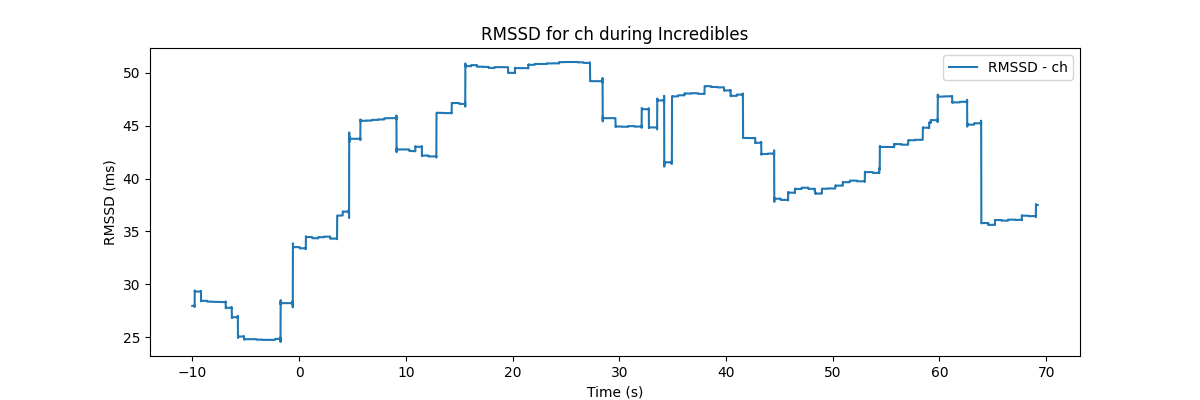

In [15]:
selected_modality = "RMSSD"  # e.g. 'EEG', 'ECG', 'IBI', 'RMSSD'
selected_member = "ch"
selected_event = "Incredibles"

member_folder = {"ch": "child", "cg": "caregiver"}[selected_member]

nc_path = os.path.join("../data/UNIWAW_imported", selected_modality, dyad_id, member_folder, 
    f"{dyad_id}_{selected_modality}_{selected_member}_{selected_event}.nc"
)
print(f"Loading: {nc_path}")
# Load to xarray
data_xr = load_xarray_from_netcdf(str(nc_path))
pprint(data_xr)
# plot the data
plt.figure(figsize=(12, 4))
plt.plot(data_xr['time'],data_xr.sel(channel='RMSSD'), label=f'{selected_modality} - {selected_member}')
plt.xlabel('Time (s)')
plt.ylabel(f'{selected_modality} (ms)')
plt.title(f'{selected_modality} for {selected_member} during {selected_event}')
plt.legend()

In [4]:
metadata = get_export_metadata(data_xr)
notch_q = metadata['eeg']['filtration']['notch']['Q']
print(f"Notch Q: {notch_q}")

Notch Q: 30
